# Comparing the Criterion Value: Original Model vs Phi Specified Model 

In [ ]:
# Magics
%reload_ext autoreload
%autoreload 2

In [ ]:
### Project Paths
from pathlib import Path
import sys
import importlib

# Change this depending on notebook location:
# 0 = notebook is 1 folder inside project root, e.g. dp_termpaper/edu1
# 1 = notebook is 2 folders inside project root, e.g. dp_termpaper/data/moments
# 2 = notebook is 3 folders inside project root
amount_of_levels = 0

DIR = Path.cwd().resolve().parents[amount_of_levels]

if str(DIR) not in sys.path:
    sys.path.insert(0, str(DIR))

import project_paths as pp
from project_imports import *

importlib.reload(pp)
jax.config.update("jax_enable_x64", True)

### Define Macros


In [ ]:
###############################################################
#### Define which education level you want to estimate for ####
###############################################################

education_levels = ["edu1", "edu2", "edu3"]

#Number og simulations to run for each model when computing criterion values
n_sim = 1000

## Load Data 

In [ ]:
education_levels = ["edu1", "edu2", "edu3"]

def load_criterion_file(model_type, education_level):
    file_path = (
        pp.COMPARISON_DIR
        / f"{model_type}_model_criterion_by_moment_{education_level}.csv"
    )
    df = pd.read_csv(file_path)
    df["model_type"] = model_type
    df["education_level"] = education_level
    return df

all_crit = pd.concat(
    [
        load_criterion_file(model_type, edu)
        for edu in education_levels
        for model_type in ["old", "new"]
    ],
    ignore_index=True,
)

all_crit.head()

,model,seed,moment,squared_error_sum,empirical_variance,weight,criterion_value,total_criterion,share_of_total_criterion,run,model_type,education_level
0,old_model_edu1,1501552845,hours_0,1.584488,0.093837,10.656734,16.885470,335.017272,0.050402,1,old,edu1
1,old_model_edu1,1501552845,hours_1,0.056986,0.000377,2649.209160,150.967626,335.017272,0.450626,1,old,edu1
2,old_model_edu1,1501552845,hours_2,0.051128,0.000660,1514.262951,77.420826,335.017272,0.231095,1,old,edu1
3,old_model_edu1,1501552845,hours_3,0.053642,0.001229,813.867913,43.657277,335.017272,0.130314,1,old,edu1
4,old_model_edu1,1501552845,hours_4,0.597698,0.061083,16.371279,9.785080,335.017272,0.029208,1,old,edu1


## 2-row figure with 100sim above and 1000sim below

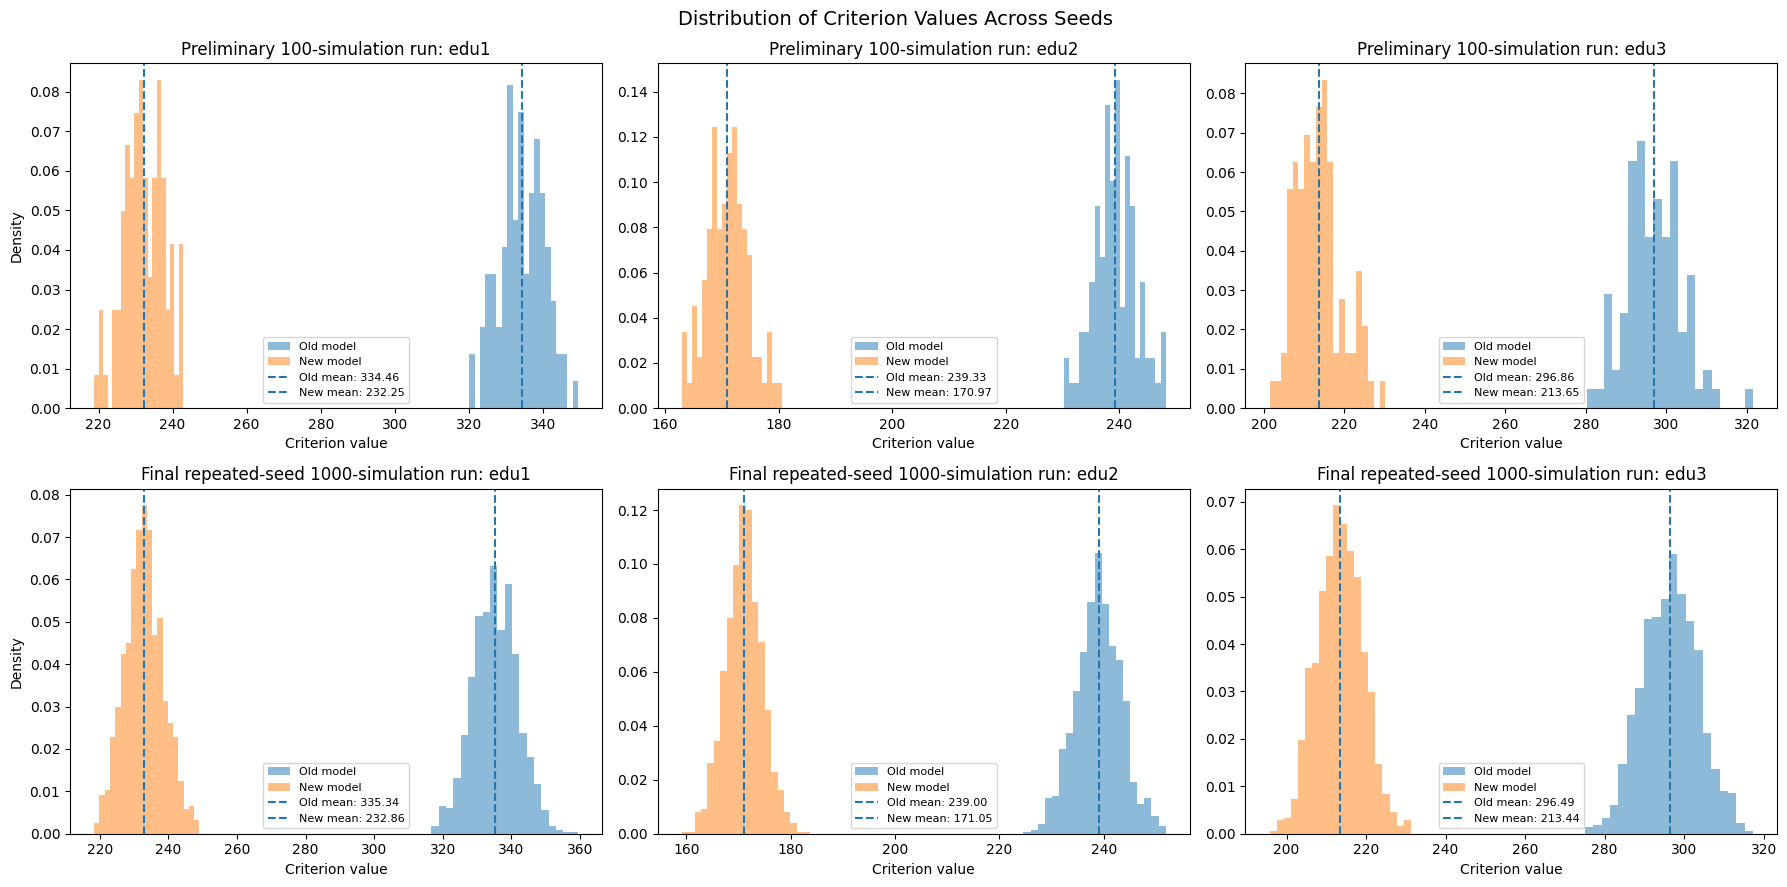

In [5]:
education_levels = ["edu1", "edu2", "edu3"]

# --- Load preliminary 100-simulation npz files ---
prelim_data = {}
for edu in education_levels:
    arr = np.load(pp.COMPARISON_DIR / f"criterion_values_{edu}_100sim.npz")
    prelim_data[edu] = {
        "old": arr["old_vals"],
        "new": arr["new_vals"],
    }

# --- Load final criterion values from CSV files ---
final_data = {}

for edu in education_levels:
    old = pd.read_csv(pp.COMPARISON_DIR / f"old_model_criterion_by_moment_{edu}.csv")
    new = pd.read_csv(pp.COMPARISON_DIR / f"new_model_criterion_by_moment_{edu}.csv")

    old_vals = (
        old
        .groupby(["run", "seed"], as_index=False)
        .agg(total_criterion=("total_criterion", "first"))
        ["total_criterion"]
        .to_numpy()
    )

    new_vals = (
        new
        .groupby(["run", "seed"], as_index=False)
        .agg(total_criterion=("total_criterion", "first"))
        ["total_criterion"]
        .to_numpy()
    )

    final_data[edu] = {
        "old": old_vals,
        "new": new_vals,
    }

# --- Plot preliminary and final distributions ---
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 9),
    sharey=False,
)

rows = [
    ("Preliminary 100-simulation run", prelim_data),
    ("Final repeated-seed 1000-simulation run", final_data),
]

for row_idx, (row_title, data_dict) in enumerate(rows):
    for col_idx, edu in enumerate(education_levels):
        ax = axes[row_idx, col_idx]

        old_vals = data_dict[edu]["old"]
        new_vals = data_dict[edu]["new"]

        ax.hist(
            old_vals,
            bins=20,
            alpha=0.5,
            density=True,
            label="Old model",
        )

        ax.hist(
            new_vals,
            bins=20,
            alpha=0.5,
            density=True,
            label="New model",
        )

        ax.axvline(
            old_vals.mean(),
            linestyle="--",
            label=f"Old mean: {old_vals.mean():.2f}",
        )

        ax.axvline(
            new_vals.mean(),
            linestyle="--",
            label=f"New mean: {new_vals.mean():.2f}",
        )

        ax.set_title(f"{row_title}: {edu}")
        ax.set_xlabel("Criterion value")

        if col_idx == 0:
            ax.set_ylabel("Density")

        ax.legend(fontsize=8)

fig.suptitle("Distribution of Criterion Values Across Seeds", fontsize=14)
plt.tight_layout()
plt.savefig(pp.PLOTS_DIR / "criterion_distribution_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
def create_moment_comparison_table(all_crit, education_level):
    old_df = all_crit.loc[
        (all_crit["education_level"] == education_level)
        & (all_crit["model_type"] == "old")
    ].copy()

    new_df = all_crit.loc[
        (all_crit["education_level"] == education_level)
        & (all_crit["model_type"] == "new")
    ].copy()

    moment_comparisons_all = old_df.merge(
        new_df,
        on=["run", "seed", "moment", "education_level"],
        suffixes=("_old", "_new"),
    )

    moment_comparisons_all["criterion_old"] = (
        moment_comparisons_all["criterion_value_old"]
    )

    moment_comparisons_all["criterion_new"] = (
        moment_comparisons_all["criterion_value_new"]
    )

    moment_comparisons_all["absolute_reduction"] = (
        moment_comparisons_all["criterion_old"]
        - moment_comparisons_all["criterion_new"]
    )

    moment_comparisons_all["percent_reduction"] = (
        moment_comparisons_all["absolute_reduction"]
        / moment_comparisons_all["criterion_old"]
    ) * 100

    avg_moment_comparison = (
        moment_comparisons_all
        .groupby("moment", as_index=False)
        .agg(
            criterion_old_mean=("criterion_old", "mean"),
            criterion_old_std=("criterion_old", "std"),
            criterion_new_mean=("criterion_new", "mean"),
            criterion_new_std=("criterion_new", "std"),
            absolute_reduction_mean=("absolute_reduction", "mean"),
            absolute_reduction_std=("absolute_reduction", "std"),
            percent_reduction_mean=("percent_reduction", "mean"),
        )
    )

    total_old = avg_moment_comparison["criterion_old_mean"].sum()
    total_new = avg_moment_comparison["criterion_new_mean"].sum()
    total_reduction = total_old - total_new

    avg_moment_comparison["old_share_of_total"] = (
        avg_moment_comparison["criterion_old_mean"] / total_old
    )

    avg_moment_comparison["new_share_of_total"] = (
        avg_moment_comparison["criterion_new_mean"] / total_new
    )

    avg_moment_comparison["share_of_total_reduction"] = (
        avg_moment_comparison["absolute_reduction_mean"]
        / total_reduction
    ) * 100

    avg_moment_comparison["education_level"] = education_level

    avg_moment_comparison = avg_moment_comparison.sort_values(
        "share_of_total_reduction",
        ascending=False,
    )

    return avg_moment_comparison, moment_comparisons_all

In [7]:
all_avg_moment_comparisons = []

for edu in education_levels:
    avg_table, full_table = create_moment_comparison_table(
        all_crit,
        education_level=edu,
    )

    all_avg_moment_comparisons.append(avg_table)

all_avg_moment_comparisons = pd.concat(
    all_avg_moment_comparisons,
    ignore_index=True,
)

all_avg_moment_comparisons

,moment,criterion_old_mean,criterion_old_std,criterion_new_mean,criterion_new_std,absolute_reduction_mean,absolute_reduction_std,percent_reduction_mean,old_share_of_total,new_share_of_total,share_of_total_reduction,education_level
0,hours_1,151.776250,6.644338,101.395640,5.943246,50.380610,3.109852,33.217040,0.452609,0.435435,49.163593,edu1
1,nowork_nowork,32.379324,0.249596,11.189205,0.147841,21.190119,0.185803,65.443676,0.096558,0.048051,20.678241,edu1
2,hours_0,16.700893,0.172500,7.082355,0.107845,9.618537,0.117932,57.593356,0.049803,0.030415,9.386188,edu1
3,hours_4,9.724953,0.162704,2.035667,0.070994,7.689286,0.141397,79.067831,0.029001,0.008742,7.503540,edu1
4,hours_2,77.644910,3.793856,70.502051,3.736061,7.142860,0.689963,9.213840,0.231543,0.302765,6.970313,edu1
5,hours_3,43.549761,2.030383,38.149436,1.998607,5.400325,0.524481,12.416614,0.129869,0.163829,5.269872,edu1
6,work_work,3.560135,0.094918,2.506428,0.085960,1.053707,0.128386,29.547050,0.010617,0.010764,1.028253,edu1
7,hours_1,67.642422,2.986811,43.858207,2.444324,23.784214,1.933191,35.157022,0.283019,0.256401,35.002516,edu2
8,hours_2,79.599785,3.474319,62.244803,3.291205,17.354982,0.951993,21.827460,0.333049,0.363891,25.540806,edu2
9,hours_3,62.837758,2.779110,50.492119,2.635849,12.345639,1.122003,19.659506,0.262916,0.295183,18.168707,edu2


### Save the mean comparison table

In [8]:
all_avg_moment_comparisons.to_csv(
    pp.COMPARISON_DIR
      / "moment_comparison_all_education_levels.csv",
    index=False,
)